# Quantium Data Analytics Task 1 : Data Preparation and Customer Analytics
## Chip Category Sales & Customer Behaviour Analysis


##  Problem Statement
Quantiums retail analytics team needs to understand chip purchasing behaviour across different customer segments to support the category manager in making strategic recommendations.

This analysis answers:
- Which customer segments drive the most chip sales?
- Which brands and pack sizes are most popular?
- Are there seasonal trends in chip purchases?
- How do Budget, Mainstream and Premium customers differ?

In [ ]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from datetime import datetime

In [ ]:
# Data Loading
df_transaction=pd.read_excel('/content/QVI_transaction_data.xlsx')
df_customer=pd.read_csv('/content/QVI_purchase_behaviour.csv')


In [ ]:
print(df_transaction.head())
print(df_customer.head)

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
<bound method NDFrame.head of        LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0                1000   YOUNG SINGLES/COUPLES          Premium
1                1002   YOUNG SINGLES/COUPLES       Mainstream
2                1003          YOUNG

# Merging

In [ ]:
df=pd.merge(df_transaction,df_customer,on='LYLTY_CARD_NBR',how="left")
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


#Standardizing Date Column Format

In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'],unit='D', origin='1899-12-30')

In [ ]:
df.isnull().sum() #Null value treatment

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [ ]:
df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

# Text Normalization: Removing Special Charecters

In [ ]:
df['PROD_NAME'] = df['PROD_NAME'].str.replace(r'[^a-zA-Z0-9\s]', '')

# Isolating Pack Size

In [ ]:
#  extracting weights into a new column
df['pack_size'] = df['PROD_NAME'].str.extract(r'(\d+)\s*[gG]', expand=False)
df['pack_size'] = df['pack_size'].astype('Int64')

# Remove the weights from the product name
df['PROD_NAME'] = df['PROD_NAME'].str.replace(r'(\d+\s*[gG])', '', regex=True)

In [ ]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,pack_size
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,YOUNG SINGLES/COUPLES,Premium,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,MIDAGE SINGLES/COUPLES,Budget,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150


In [ ]:
words = df['PROD_NAME'].str.split()
all_words = np.concatenate(words).tolist()
print(Counter(all_words).most_common()) #counts

[('Chips', 49770), ('Kettle', 41288), ('&', 35565), ('Smiths', 28860), ('Salt', 27976), ('Cheese', 27890), ('Pringles', 25102), ('Doritos', 24962), ('Crinkle', 23960), ('Corn', 22063), ('Original', 21560), ('Cut', 20754), ('Chip', 18645), ('Chicken', 18577), ('Salsa', 18094), ('Sea', 14145), ('Thins', 14075), ('Sour', 13882), ('Crisps', 12607), ('Vinegar', 12402), ('Chilli', 12389), ('RRD', 11894), ('Infuzions', 11057), ('Supreme', 10963), ('WW', 10320), ('Cobs', 9693), ('Popd', 9693), ('Tortilla', 9580), ('Tostitos', 9471), ('Twisties', 9454), ('Sensations', 9429), ('Old', 9324), ('El', 9324), ('Paso', 9324), ('Dip', 9324), ('Sweet', 7883), ('Lime', 7852), ('Tomato', 7669), ('Cream', 7618), ('Thinly', 7507), ('Tyrrells', 6442), ('And', 6373), ('BBQ', 6351), ('Tangy', 6332), ('Grain', 6272), ('Waves', 6272), ('Lightly', 6248), ('Salted', 6248), ('Soy', 6121), ('Natural', 6050), ('Mild', 6048), ('Red', 5885), ('Rock', 5885), ('Deli', 5885), ('Thai', 4737), ('Burger', 4733), ('Swt', 4718

#Filtering: Identifying and Excluding Non-Chip Products

In [ ]:
df['PROD_NAME'].str.contains('Salsa').value_counts()

,count
PROD_NAME,
False,246742
True,18094


In [ ]:
salsa = df[df['PROD_NAME'].str.contains('Salsa')]


In [ ]:
df['PROD_NAME'].str.contains('Dip|dip').value_counts()

,count
PROD_NAME,
False,254074
True,10762


In [ ]:
dips = df[df['PROD_NAME'].str.contains('Dip|dip')]

In [ ]:
df = df[~df['PROD_NAME'].str.contains(r'salsa|dip', case=False, regex=True)]
df.shape

(245304, 11)

# Identifying Product Sizing Trends

<Axes: xlabel='pack_size', ylabel='PROD_NAME'>

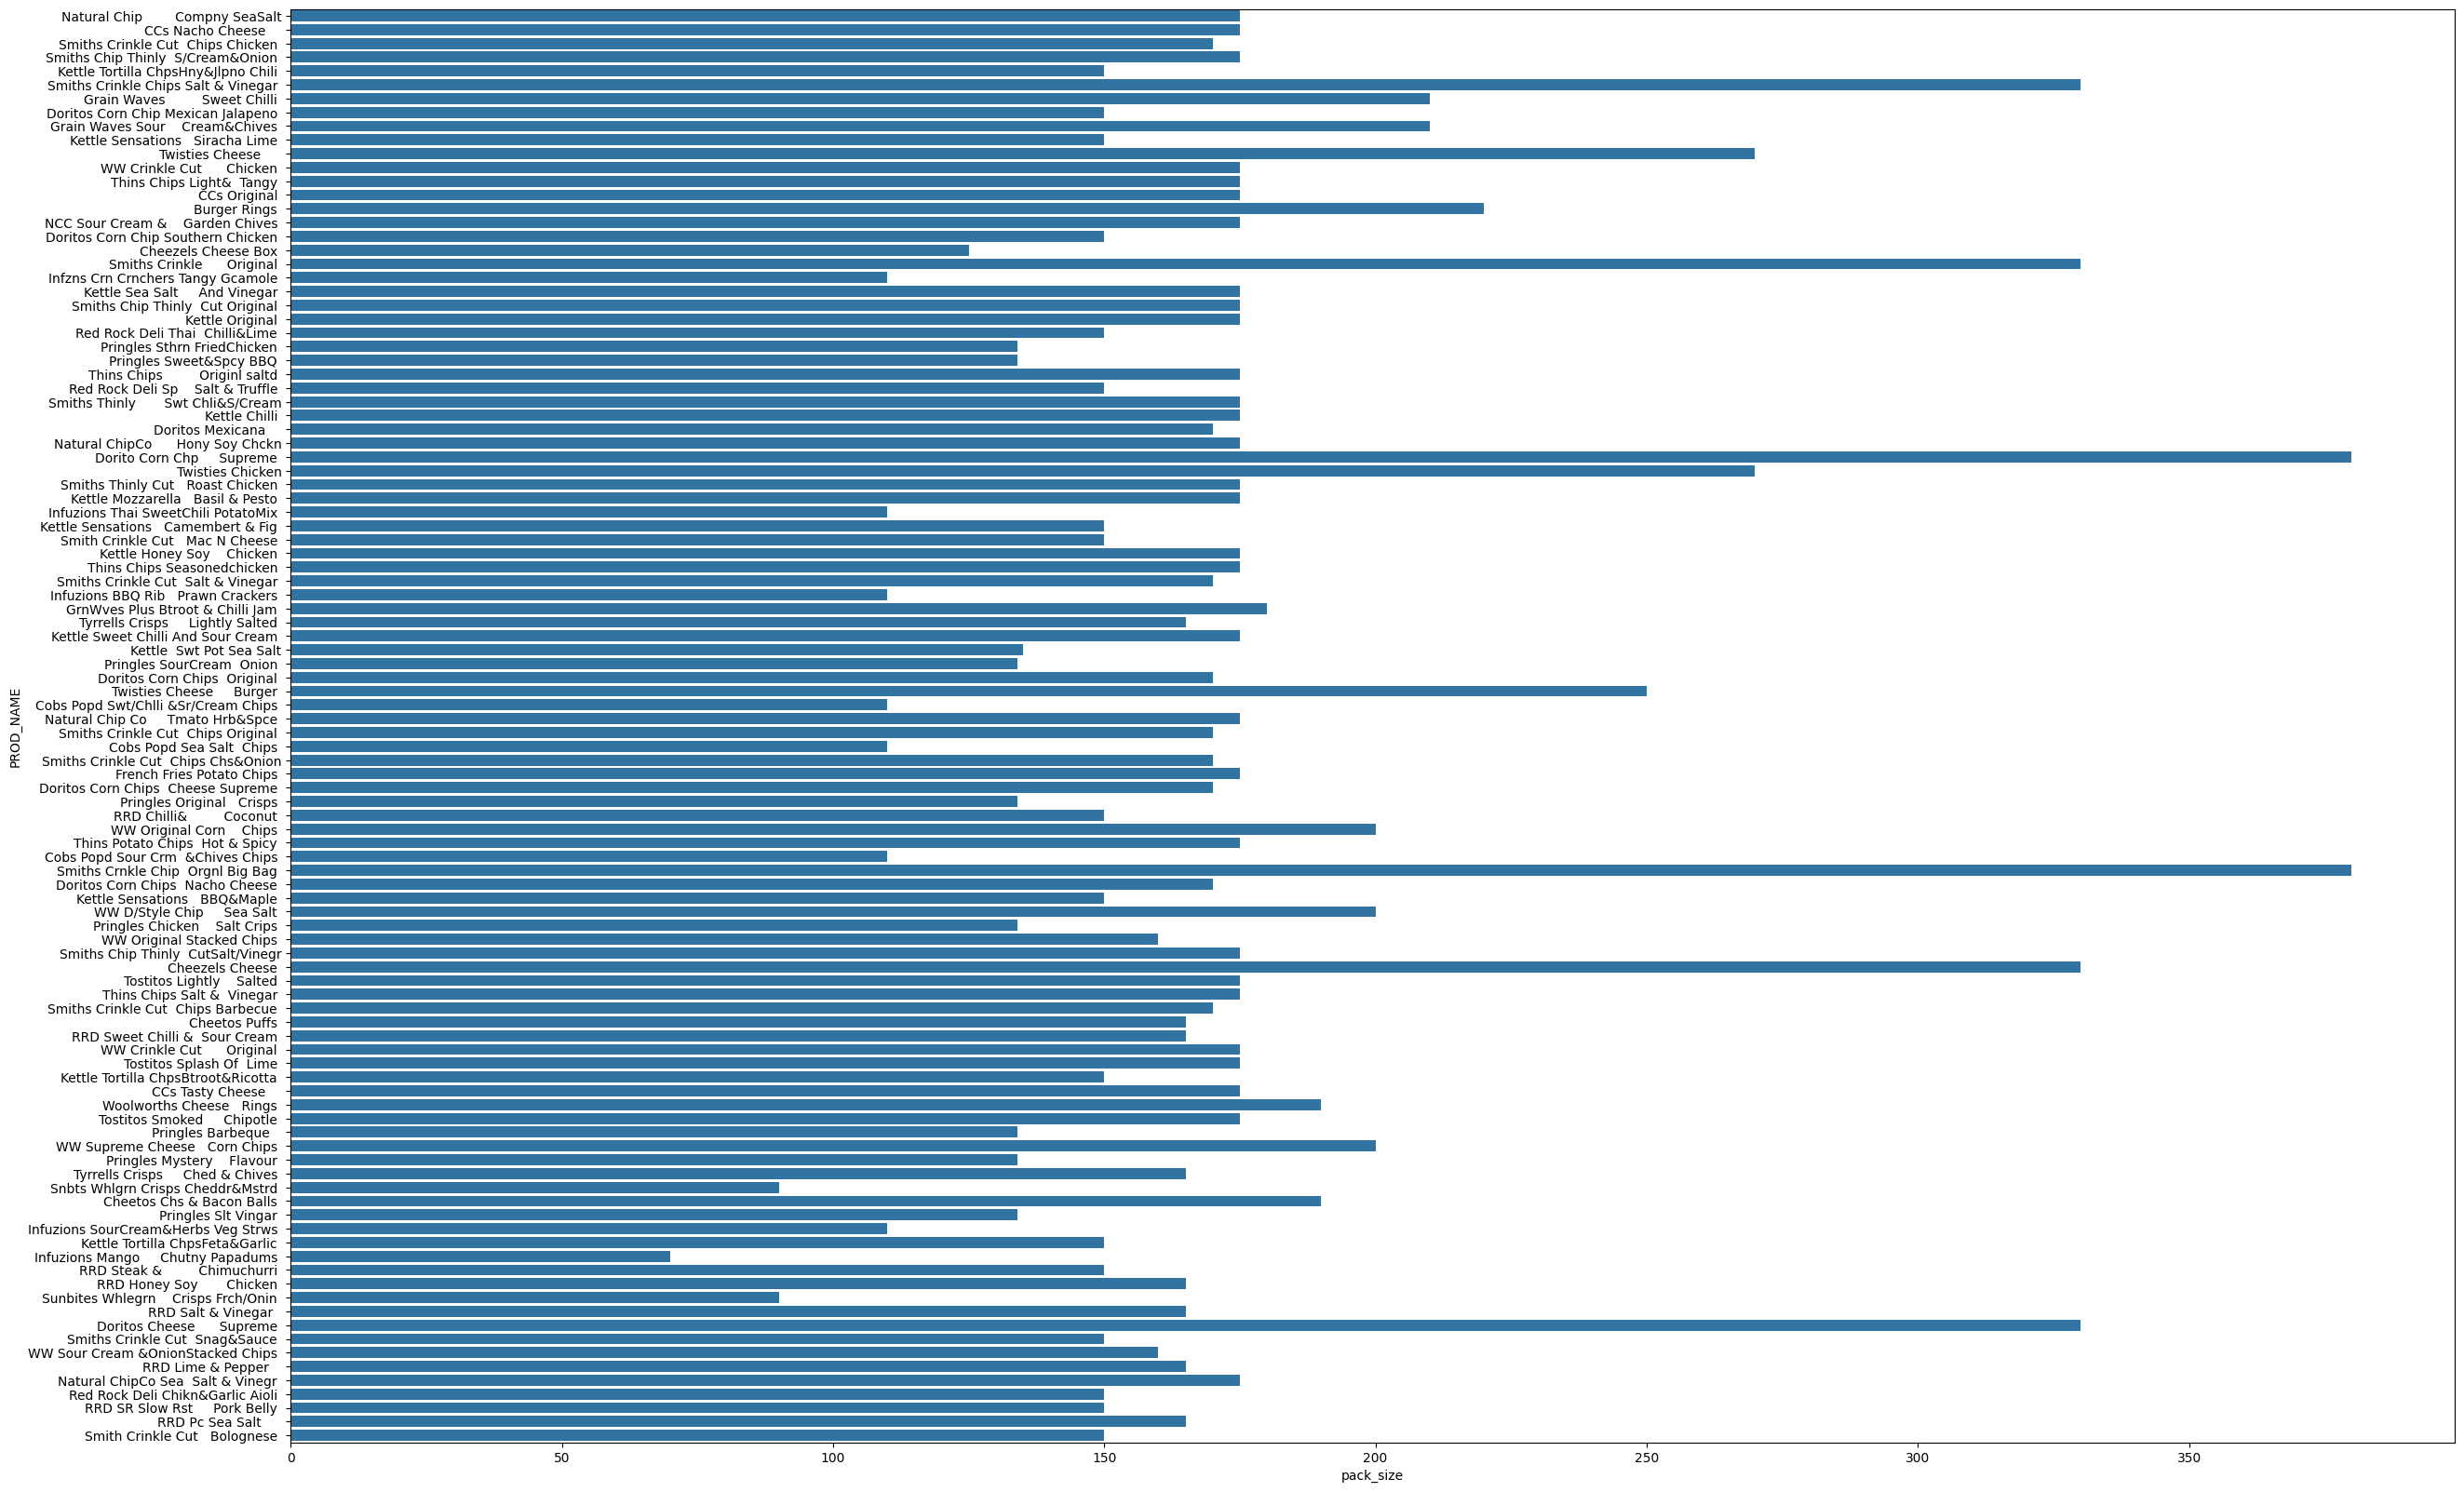

In [ ]:
plt.figure(figsize=(30, 20))
sns.barplot(x='pack_size', y='PROD_NAME', data=df)

# Identifying high-performing Pack sizes

<Axes: xlabel='pack_size', ylabel='TOT_SALES'>

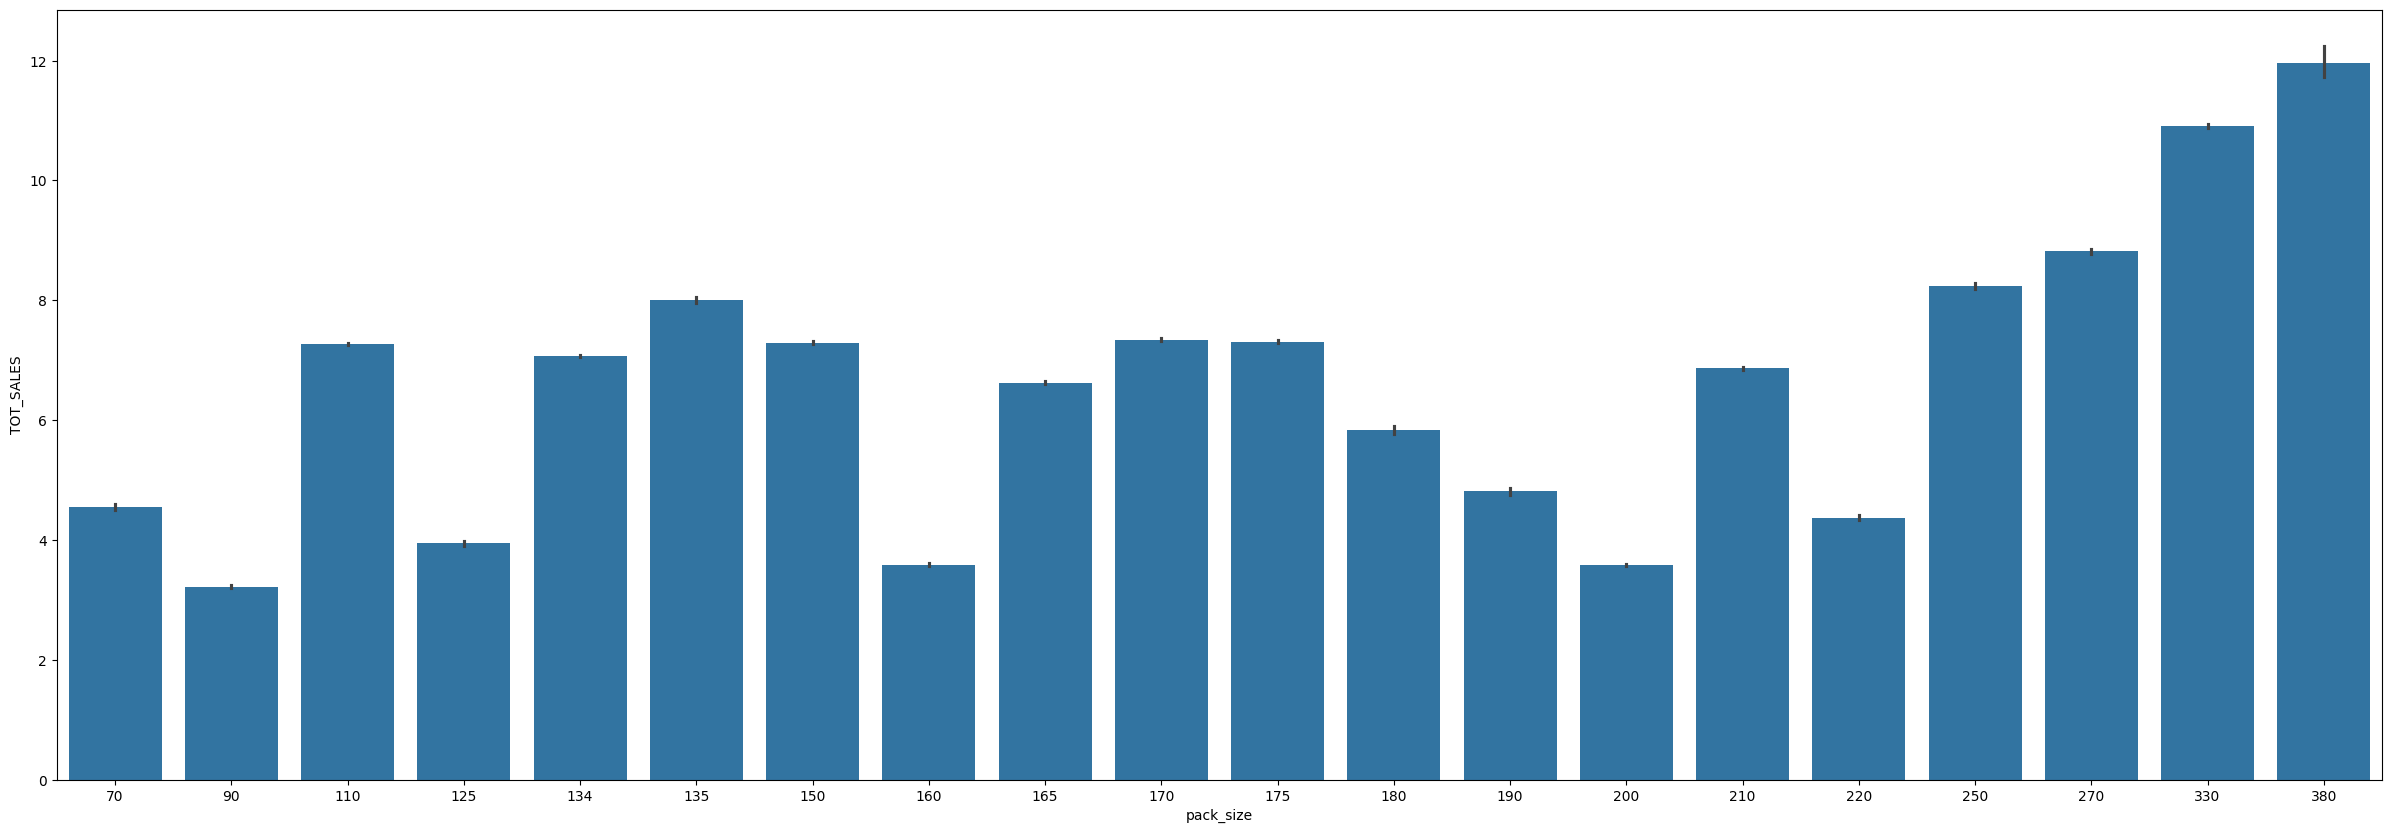

In [ ]:
plt.figure(figsize=(30, 10))
sns.barplot(x='pack_size',y = 'TOT_SALES', data=df)


### This Barplot clearly reveals, bigger packaged chips have higher sales.

# Checking for Outliers

<Axes: xlabel='PROD_QTY'>

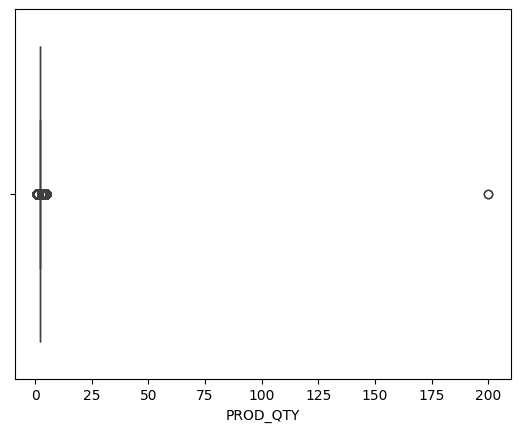

In [ ]:
sns.boxplot(x='PROD_QTY', data=df) #there is an outlier

In [ ]:
ot = df.loc[df['PROD_QTY'] > 180]
print(ot)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                          PROD_NAME  PROD_QTY  TOT_SALES       LIFESTAGE  \
69762  Dorito Corn Chp     Supreme        200      650.0  OLDER FAMILIES   
69763  Dorito Corn Chp     Supreme        200      650.0  OLDER FAMILIES   

      PREMIUM_CUSTOMER  pack_size  
69762          Premium        380  
69763          Premium        380  


### Analysis of the extreme outliers shows two transactions of 200 units by a single customer.
###These are likely commercial purchases and have been removed to prevent skewness.

In [ ]:
df = df.drop(df[df['PROD_QTY'] == 200].index)
df.shape

(245302, 11)

### Identifying Missing Dates

In [ ]:
df.DATE.nunique() #one value is missing


364

In [ ]:
# Creating the full range
full_range = pd.date_range(start=df['DATE'].min(), end=df['DATE'].max())
missing_dates = full_range.difference(df['DATE'])
missing_dates

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

##### 12-25-2018 is the  missing date

### Resolving the missing Christmas day data

In [ ]:
missing_date_row = pd.DataFrame({'DATE': ['2018-12-25'], 'TOT_SALES': [0]}) #keeping sales -0
df = pd.concat([df, missing_date_row])

In [ ]:
df.DATE.nunique()

365

##### By generating a full data range,Christmas day was identified as missing. A zero-sales record was imputed for this date to ensure a continous time series.

(np.float64(17866.0), np.float64(17897.0))

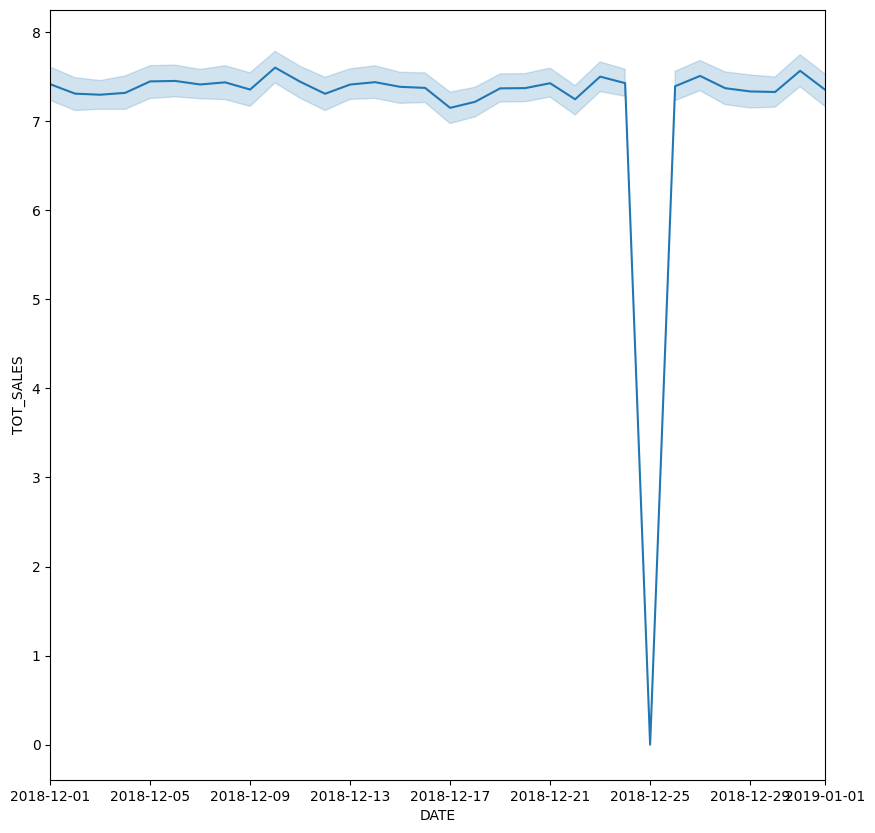

In [ ]:
plt.figure(figsize=(10, 10))
ax = sns.lineplot(x='DATE', y='TOT_SALES', data=df).axes
ax.set_xlim(pd.Timestamp('2018-12-01'), pd.Timestamp('2019-01-01'))

# Time Series Analysis:Annual Sales Volume

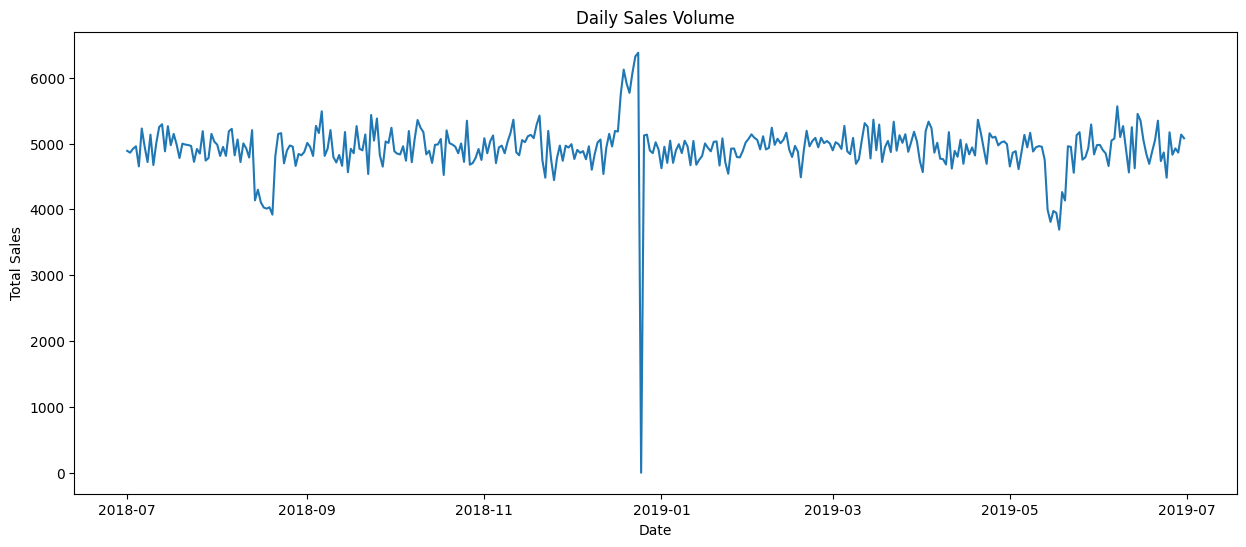

In [ ]:
daily_sales = df.groupby('DATE')['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(15,6))
sns.lineplot(x='DATE', y='TOT_SALES', data=daily_sales)
plt.title('Daily Sales Volume')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

(np.float64(17862.0), np.float64(17926.0))

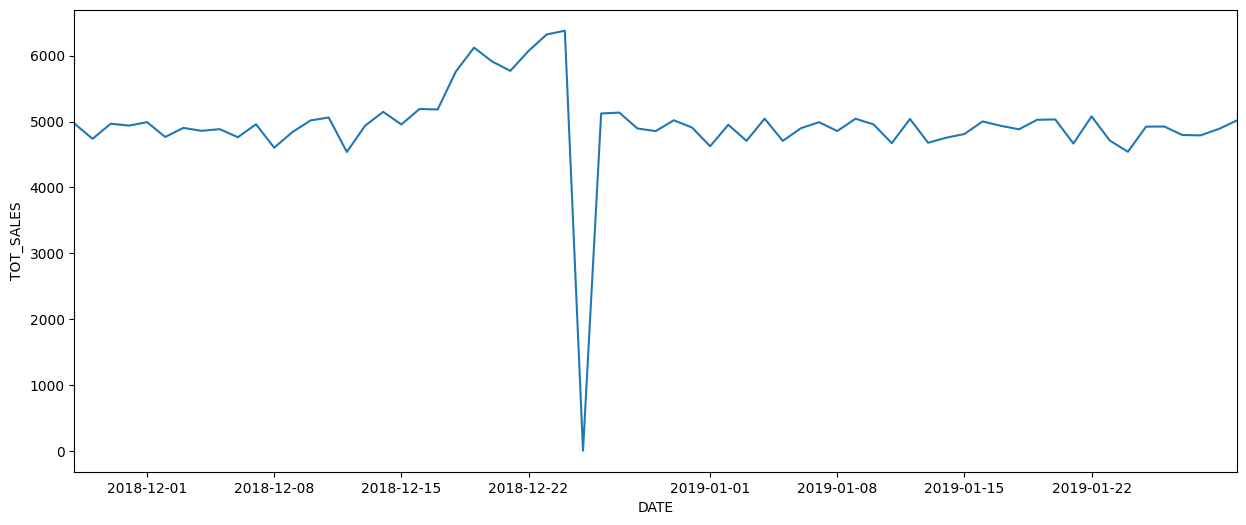

In [ ]:
plt.figure(figsize=(15, 6))
ax=sns.lineplot(x='DATE', y='TOT_SALES', data=daily_sales).axes
ax.set_xlim(pd.Timestamp('2018-11-27'),pd.Timestamp('2019-01-30'))

### The sales volume indicates strong seasonal perfomance in December.

(np.float64(17713.0), np.float64(17775.0))

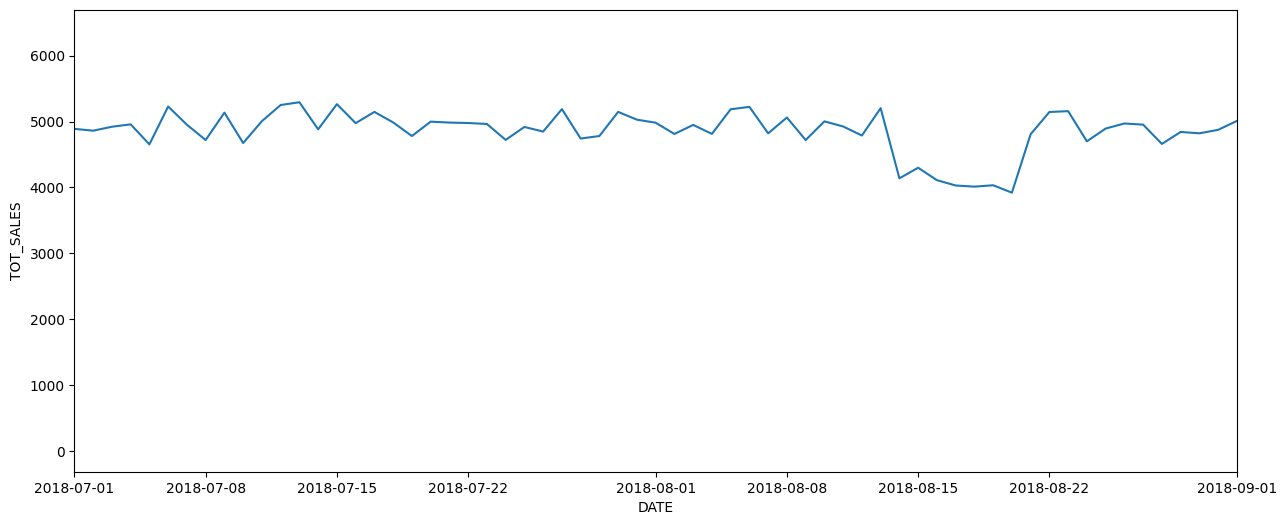

In [ ]:
plt.figure(figsize=(15, 6))
ax = sns.lineplot(x='DATE', y='TOT_SALES', data=daily_sales).axes
ax.set_xlim(pd.Timestamp('2018-07-01'), pd.Timestamp('2018-09-01'))

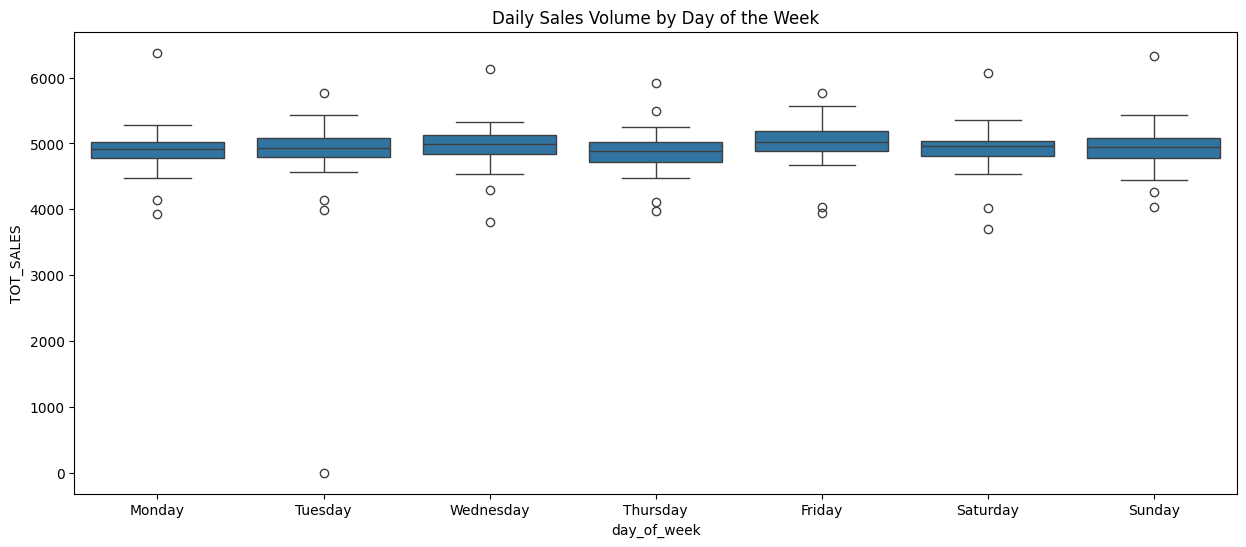

In [ ]:
daily_sales['DATE'] = pd.to_datetime(daily_sales['DATE'])
daily_sales['day_of_week'] = daily_sales['DATE'].dt.day_name()
plt.figure(figsize=(15, 6))
sns.boxplot(x='day_of_week', y='TOT_SALES', data=daily_sales, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Daily Sales Volume by Day of the Week')
plt.show()

### While minor fluctuations are visible in August and September,the boxplot confirms that the median sales remain stable across all days of the week.

(np.float64(18017.0), np.float64(18078.0))

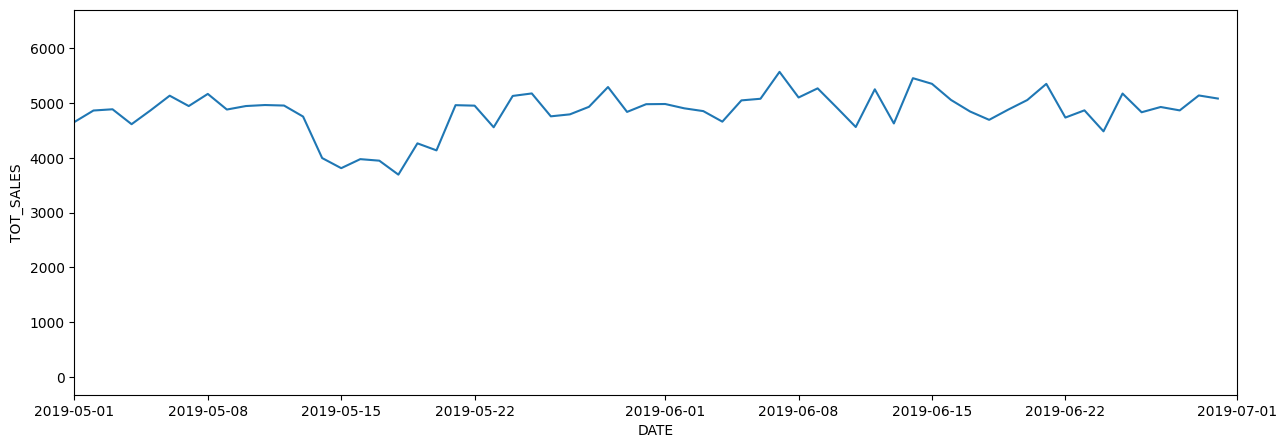

In [ ]:
plt.figure(figsize=(15, 5))
ax = sns.lineplot(x='DATE', y='TOT_SALES', data=daily_sales).axes
ax.set_xlim(pd.Timestamp('2019-05-01'), pd.Timestamp('2019-07-01'))

### A noticeable dip in sales occured around mid-May 2019.However as with the fluctuations in August and September,this likely represents standard weekly variability or a short term trend rather than a significant market shift

In [ ]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,pack_size,BRAND
0,2018-10-17 00:00:00,1.0,1000.0,1.0,5.0,Natural Chip Compny SeaSalt,2.0,6.0,YOUNG SINGLES/COUPLES,Premium,175,Natural
1,2019-05-14 00:00:00,1.0,1307.0,348.0,66.0,CCs Nacho Cheese,3.0,6.3,MIDAGE SINGLES/COUPLES,Budget,175,CCs
2,2019-05-20 00:00:00,1.0,1343.0,383.0,61.0,Smiths Crinkle Cut Chips Chicken,2.0,2.9,MIDAGE SINGLES/COUPLES,Budget,170,Smiths
3,2018-08-17 00:00:00,2.0,2373.0,974.0,69.0,Smiths Chip Thinly S/Cream&Onion,5.0,15.0,MIDAGE SINGLES/COUPLES,Budget,175,Smiths
4,2018-08-18 00:00:00,2.0,2426.0,1038.0,108.0,Kettle Tortilla ChpsHny&Jlpno Chili,3.0,13.8,MIDAGE SINGLES/COUPLES,Budget,150,Kettle


# Extracting Brand Names from Product Descriptions

In [ ]:
df['BRAND'] = df['PROD_NAME'].str.split().str[0]
df['BRAND'] = df['BRAND'].replace({'NCC': 'Natural Chip', 'Infzns': 'Infuzions', 'RRD': 'Red', 'Snbts': 'Sunbites','Dorito':'Doritos',
                                   'Smith': 'Smiths','GrnWves': 'Grain Waves','WW':'Woolworths','Grain':'Grain Waves','Natural': 'Natural Chip'})
#cleaning and standardizing Brand labels

##Histogram of Brand Frequency

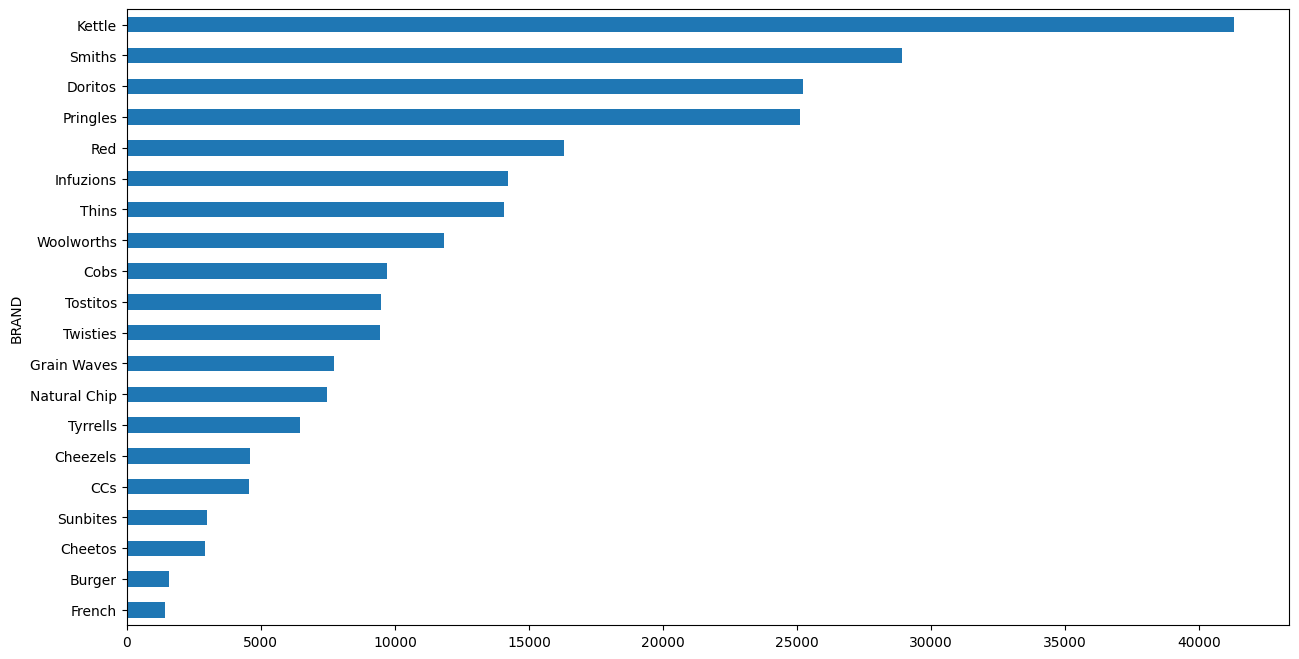

In [ ]:
df['BRAND'].value_counts(ascending=True).plot.barh(figsize=(15, 8))
plt.show()

### The market is heavily dominated by a few players.Kettle and Smiths are the clear leaders  in transaction volume.

In [ ]:
most=df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].agg(['sum']).sort_values(ascending=False,by='sum')
most

sum
LIFESTAGE              PREMIUM_CUSTOMER           
OLDER FAMILIES         Budget            156096.75
YOUNG SINGLES/COUPLES  Mainstream        147244.20
RETIREES               Mainstream        144677.55
YOUNG FAMILIES         Budget            129151.15
OLDER SINGLES/COUPLES  Budget            127279.80
                       Mainstream        124089.50
                       Premium           123147.55
RETIREES               Budget            105586.10
OLDER FAMILIES         Mainstream         96059.95
RETIREES               Premium            91013.25
YOUNG FAMILIES         Mainstream         85919.65
MIDAGE SINGLES/COUPLES Mainstream         84500.25
YOUNG FAMILIES         Premium            78176.50
OLDER FAMILIES         Premium            74899.40
YOUNG SINGLES/COUPLES  Budget             56807.50
MIDAGE SINGLES/COUPLES Premium            54254.05
YOUNG SINGLES/COUPLES  Premium            38875.50
MIDAGE SINGLES/COUPLES Budget             33150.70
NEW FAMILIES           Budget             20534.65
                       Mainstream         15935.50
                       Premium            10732.20

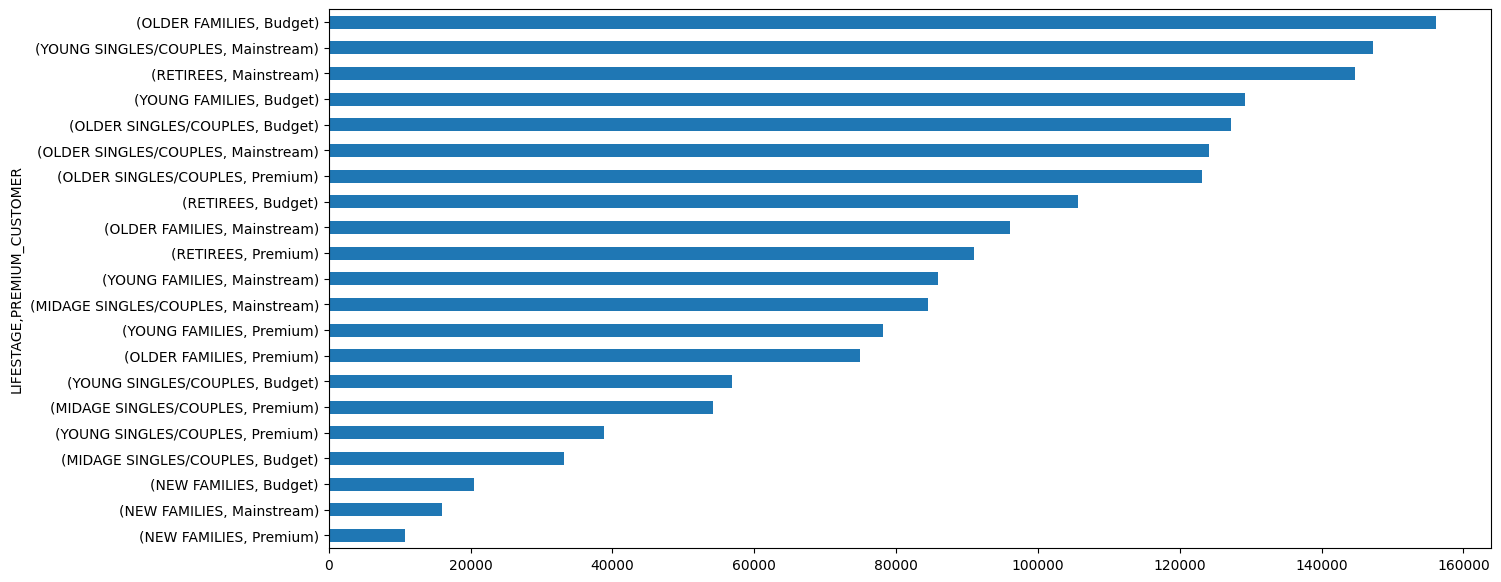

In [ ]:
most['sum'].sort_values().plot.barh(figsize=(15, 7))
plt.show()

##### Budget Older Families,Mainstream Young singles/couples and Mainstream REtirees are the most valuable segments,each contributing over 140,000 in total sales.

##### Both Older and Young families generate their highest sales in Budget segment,indicating that households with children are more price sensitive.

In [ ]:
chips_per_seg=df.groupby(["LYLTY_CARD_NBR",'LIFESTAGE','PREMIUM_CUSTOMER']).count()['DATE']
chips_per_seg.to_frame()

,,,DATE
LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,
1000.0,YOUNG SINGLES/COUPLES,Premium,1
1002.0,YOUNG SINGLES/COUPLES,Mainstream,1
1003.0,YOUNG FAMILIES,Budget,2
1004.0,OLDER SINGLES/COUPLES,Mainstream,1
1005.0,MIDAGE SINGLES/COUPLES,Mainstream,1
...,...,...,...
2370651.0,MIDAGE SINGLES/COUPLES,Mainstream,1
2370701.0,YOUNG FAMILIES,Mainstream,1
2370751.0,YOUNG FAMILIES,Premium,1


#### Older and Young Families typically buy more packs per customer compared to singles,likely due to larger household sizes.

In [ ]:
shop_chips_seg =chips_per_seg.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg(['mean']).sort_values(ascending=False,by=('mean'))
shop_chips_seg

mean
LIFESTAGE              PREMIUM_CUSTOMER          
OLDER FAMILIES         Mainstream        4.733645
                       Budget            4.638081
                       Premium           4.635711
YOUNG FAMILIES         Budget            4.467223
                       Premium           4.466416
                       Mainstream        4.421543
OLDER SINGLES/COUPLES  Budget            3.525728
                       Premium           3.522120
                       Mainstream        3.491553
MIDAGE SINGLES/COUPLES Mainstream        3.351942
RETIREES               Budget            3.234918
MIDAGE SINGLES/COUPLES Premium           3.199831
RETIREES               Premium           3.197742
MIDAGE SINGLES/COUPLES Budget            3.163946
RETIREES               Mainstream        3.131600
NEW FAMILIES           Mainstream        2.628019
                       Budget            2.585635
                       Premium           2.577391
YOUNG SINGLES/COUPLES  Mainstream        2.462317
                       Premium           2.349636
                       Budget            2.340859

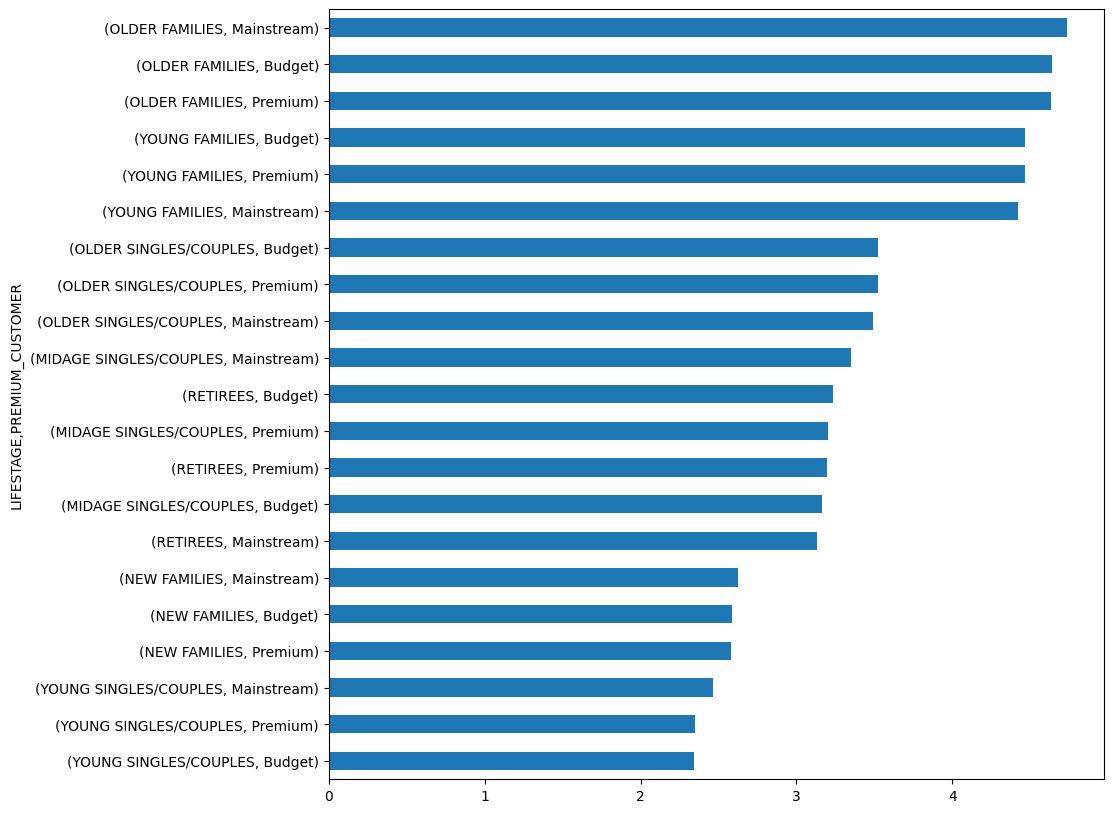

In [ ]:
shop_chips_seg['mean'].sort_values().plot.barh(figsize=(10, 10))
plt.show()

#### Mainstream Older Families takes the top spot,showing this segment isn't just large in total sales

###Older and Young Families across all tiers buy the most units per customer ,averaging 4.4 to 4.7 packs.

In [ ]:
df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['BRAND'].agg(pd.Series.mode).sort_values().to_frame()


BRAND
LIFESTAGE              PREMIUM_CUSTOMER        
MIDAGE SINGLES/COUPLES Budget            Kettle
YOUNG SINGLES/COUPLES  Budget            Kettle
YOUNG FAMILIES         Premium           Kettle
                       Mainstream        Kettle
                       Budget            Kettle
RETIREES               Premium           Kettle
                       Mainstream        Kettle
                       Budget            Kettle
OLDER SINGLES/COUPLES  Premium           Kettle
YOUNG SINGLES/COUPLES  Mainstream        Kettle
OLDER SINGLES/COUPLES  Mainstream        Kettle
OLDER FAMILIES         Premium           Kettle
                       Mainstream        Kettle
                       Budget            Kettle
NEW FAMILIES           Premium           Kettle
                       Mainstream        Kettle
                       Budget            Kettle
MIDAGE SINGLES/COUPLES Premium           Kettle
                       Mainstream        Kettle
OLDER SINGLES/COUPLES  Budget            Kettle
YOUNG SINGLES/COUPLES  Premium           Kettle

####Kettle is the favourite brand across every single customer segment,regardless of lifestage or premium status.

####The fact that even Budget and Premium segments both prefer Kettle suggests the brand succesfully hits a sweet spot of quality and value

In [ ]:
avg_amount=(df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PROD_QTY'].sum() / df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique()).sort_values(ascending=False)

In [ ]:
avg_amount

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          9.226456
                        Budget              9.022579
                        Premium             9.020637
YOUNG FAMILIES          Budget              8.672235
                        Premium             8.656237
                        Mainstream          8.584793
OLDER SINGLES/COUPLES   Budget              6.751395
                        Premium             6.741825
                        Mainstream          6.673259
MIDAGE SINGLES/COUPLES  Mainstream          6.408677
RETIREES                Budget              6.125457
                        Premium             6.081145
MIDAGE SINGLES/COUPLES  Premium             6.052809
                        Budget              5.991837
RETIREES                Mainstream          5.908274
NEW FAMILIES            Mainstream          4.882850
                        Budget              4.800184
                        Premium             4.796522
YOUNG SINGLES/COUPLES   Mainstream          4.564365
                        Premium             4.246968
                        Budget              4.234306
dtype: float64

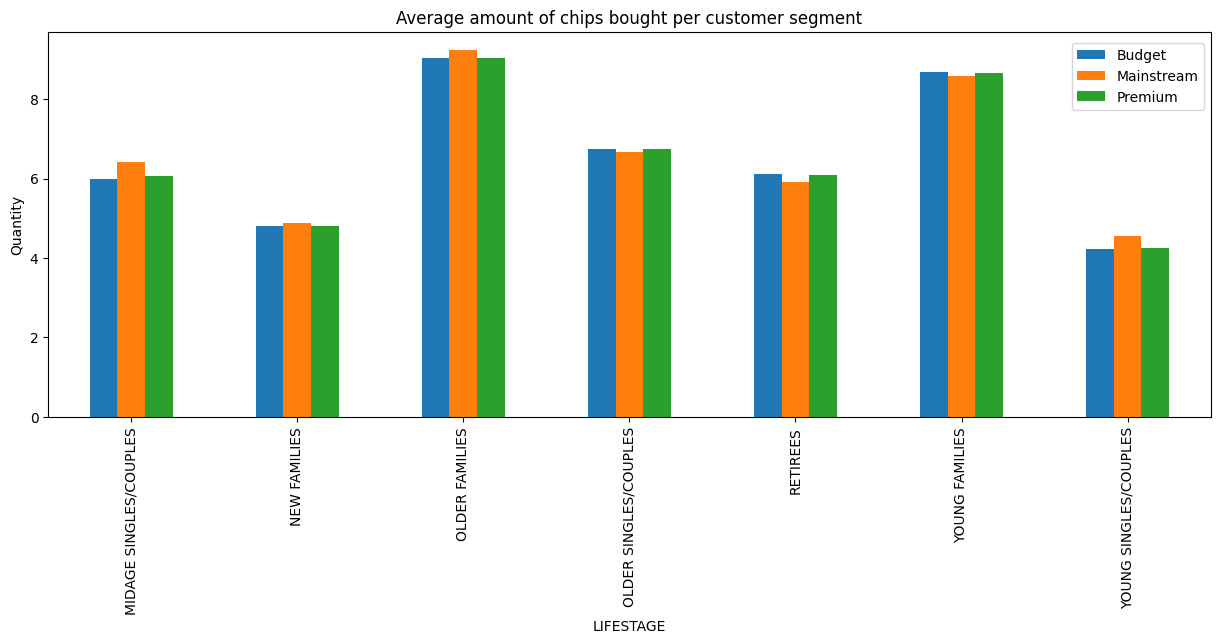

In [ ]:
avg_amount.unstack().plot.bar(figsize=(15,5))
plt.title('Average amount of chips bought per customer segment')
plt.legend(loc="upper right",bbox_to_anchor=(1.0,0.99))
plt.ylabel("Quantity")
plt.show()

#### Older and Young Families purchasethe highest quantity of chips per customer,significantly outpacing all other segments.

#### Across all lifestages,the average quantity remains remarkably consistent between Budget,Mainstream and Premium tiers

# Key Findings & Recommendations

| Finding | Insight |
|---|---|
|  Top segments | Budget Older Families, Mainstream Young Singles/Couples |
|  Most popular brand | Kettle — preferred across ALL customer segments |
|  Pack size trend | Larger packs drive higher total sales |
|  Seasonal peak | Strong sales spike in December |
|  Family behaviour | Families buy more packs per visit than singles |
|  Price sensitivity | Budget families are most price-sensitive |